# Bill Color Detection

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('Images/bills.png')
if image is None:
    raise FileNotFoundError("Image not found.")

image = cv2.resize(image, (640, 480))  # Resize if needed

# Convert to RGB (for display) and HSV (for color detection)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

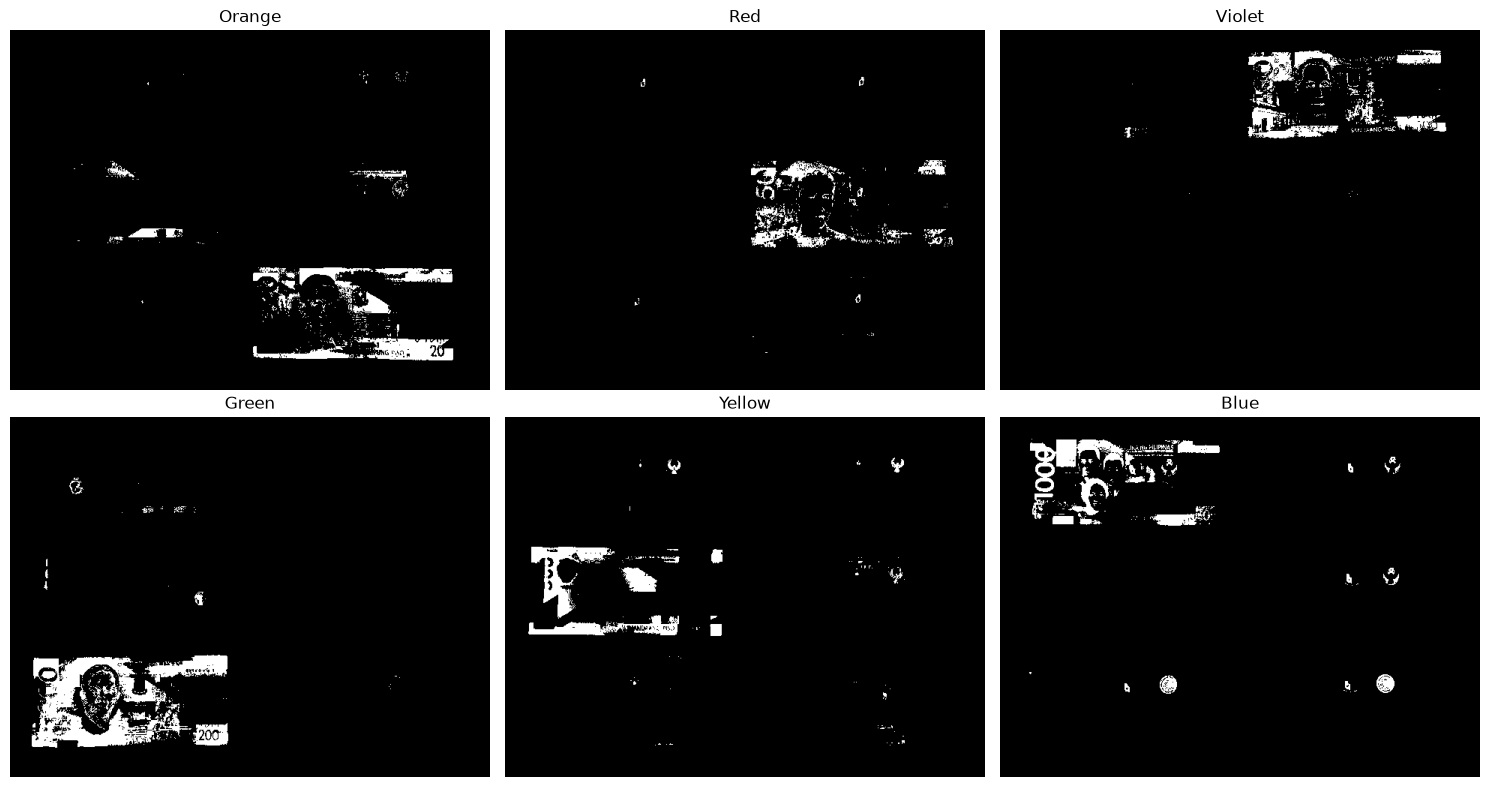

In [27]:
bill_colors = {
    'Orange':   {'ranges': [((10,   100, 100), (17,  255, 255))],
                    'box_color': (255, 140, 0),   'value': 20},
    'Red':      {'ranges': [((175, 100, 100), (180, 255, 255))],
                    'box_color': (255, 0, 0),     'value': 50},
    'Violet':   {'ranges': [((140, 40,  50), (162, 255, 220))],
                    'box_color': (148, 0, 211),   'value': 100},
    'Green':    {'ranges': [((40,  35,  40), (60,  255, 255))],
                    'box_color': (0, 150, 0),     'value': 200},
    'Yellow':   {'ranges': [((18,  90, 90), (27,  255, 255))],
                    'box_color': (255, 215, 0),   'value': 500},
    'Blue':     {'ranges': [((92,  60,  50), (114, 255, 220))],
                    'box_color': (0, 0, 255),     'value': 1000},
}

def build_mask(hsv_img, ranges):
    """Combine one or more HSV ranges (red wraps around 0/180) into a single mask."""
    mask = np.zeros(hsv_img.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        m = cv2.inRange(hsv_img, np.array(lower), np.array(upper))
        mask = cv2.bitwise_or(mask, m)
    return mask

# Preview the raw partial-color mask for every denomination
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
for ax, (label, info) in zip(axs.flatten(), bill_colors.items()):
    mask = build_mask(hsv, info['ranges'])
    ax.imshow(mask, cmap='gray')
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [28]:
h, w = image.shape[:2]

# Scale the morphology kernel and the minimum blob size to the image resolution
k_size = max(15, int(min(h, w) * 0.06))
if k_size % 2 == 0:
    k_size += 1
close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_size, k_size))
noise_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
min_area = int(h * w * 0.015)  # ignore blobs smaller than ~1.5% of the image

detections = []  # (label, value, (x, y, box_w, box_h))

for label, info in bill_colors.items():
    mask = build_mask(hsv, info['ranges'])
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, noise_kernel)        # remove speckle noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_kernel, iterations=2)  # bridge gaps
    mask = cv2.dilate(mask, close_kernel, iterations=1)                # grow to full bill size

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in contours:
        if cv2.contourArea(c) < min_area:
            continue
        x, y, box_w, box_h = cv2.boundingRect(c)
        detections.append((label, info['value'], (x, y, box_w, box_h)))

print(f"Detected {len(detections)} bill(s).")

Detected 6 bill(s).


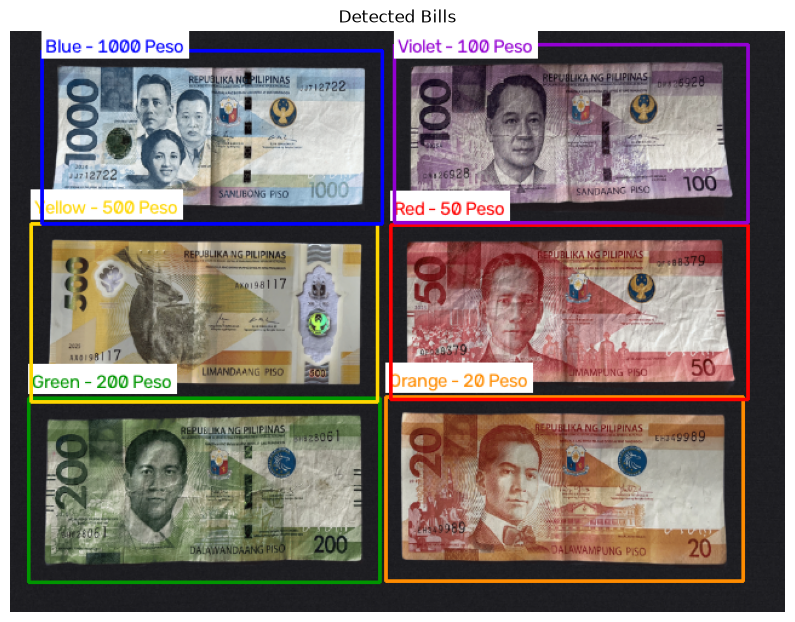

Detected bills:
  Orange: 20 Peso
  Red: 50 Peso
  Violet: 100 Peso
  Green: 200 Peso
  Yellow: 500 Peso
  Blue: 1000 Peso

Total count: 6
Total value: P1870


In [29]:
# Draw a labeled box on every detected bill
output_img = image_rgb.copy()

for label, value, (x, y, box_w, box_h) in detections:
    color = bill_colors[label]['box_color']
    cv2.rectangle(output_img, (x, y), (x + box_w, y + box_h), color, 2)

    text = f"{label} - {value} Peso"
    (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    text_y = max(y - 8, text_h + 4)
    cv2.rectangle(output_img, (x, text_y - text_h - 6), (x + text_w + 6, text_y + 4), (255, 255, 255), -1)
    cv2.putText(output_img, text, (x + 3, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

plt.figure(figsize=(10, 8))
plt.imshow(output_img)
plt.title("Detected Bills")
plt.axis("off")
plt.show()

# Summary + total peso value
print("Detected bills:")
total_value = 0
for label, value, box in detections:
    print(f"  {label}: {value} Peso")
    total_value += value

print(f"\nTotal count: {len(detections)}")
print(f"Total value: P{total_value}")